In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Parallel, delayed

In [2]:
PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
from src.morphology_features import (
    MORPHOLOGY_FEATURES,
    compute_morphology_features,
)

print("Количество признаков:", len(MORPHOLOGY_FEATURES))

Количество признаков: 27


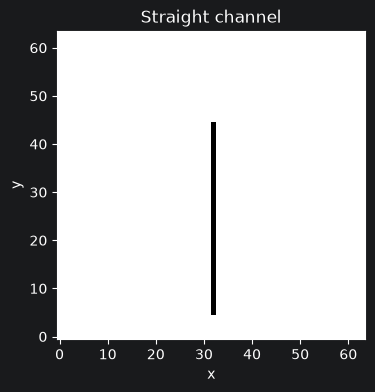

In [4]:
straight_mask = np.zeros((64, 64), dtype=np.uint8)
straight_mask[5:45, 32] = 1

straight_features = compute_morphology_features(straight_mask)

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(straight_mask, cmap="gray_r", origin="lower")
ax.set(title="Straight channel", xlabel="x", ylabel="y")
plt.show()

In [5]:
assert straight_features["area"] == 40
assert straight_features["endpoint_count"] == 1
assert straight_features["branching_points"] == 0
assert straight_features["main_path_length"] == 39
assert np.isclose(straight_features["mean_branch_length"], 39.0)
assert np.isclose(straight_features["sinuosity"], 1.0)
assert np.isclose(straight_features["side_branch_fraction"], 0.0)

straight_result = pd.Series(straight_features, name="value")

display(
    straight_result.loc[
        [
            "area",
            "endpoint_count",
            "branching_points",
            "mean_branch_length",
            "main_path_length",
            "sinuosity",
            "side_branch_fraction",
            "fractal_dimension",
        ]
    ].to_frame()
)

,value
area,40.00000
endpoint_count,1.00000
branching_points,0.00000
mean_branch_length,39.00000
main_path_length,39.00000
sinuosity,1.00000
side_branch_fraction,0.00000
fractal_dimension,0.86591


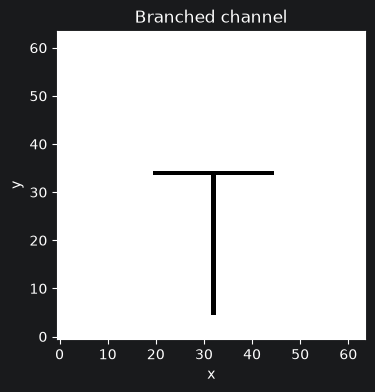

In [6]:
branched_mask = np.zeros((64, 64), dtype=np.uint8)
branched_mask[5:35, 32] = 1
branched_mask[34, 20:45] = 1

branched_features = compute_morphology_features(branched_mask)

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(branched_mask, cmap="gray_r", origin="lower")
ax.set(title="Branched channel", xlabel="x", ylabel="y")
plt.show()

In [7]:
assert branched_features["area"] == 54
assert branched_features["endpoint_count"] == 2
assert branched_features["branching_points"] == 1
assert branched_features["main_path_length"] == 41
assert branched_features["sinuosity"] > 1.0
assert branched_features["side_branch_fraction"] > 0.0

selected_features = [
    "area",
    "width_fraction",
    "anisotropy",
    "endpoint_count",
    "branching_points",
    "branching_density",
    "mean_branch_length",
    "max_branch_length",
    "main_path_length",
    "sinuosity",
    "side_branch_fraction",
    "fractal_dimension",
]

comparison = pd.DataFrame(
    [straight_features, branched_features],
    index=["straight", "branched"],
)

display(comparison[selected_features].T)

,straight,branched
area,40.00000,54.000000
width_fraction,0.00000,0.380952
anisotropy,1.00000,0.590605
endpoint_count,1.00000,2.000000
branching_points,0.00000,1.000000
branching_density,0.00000,0.018519
mean_branch_length,39.00000,17.666667
max_branch_length,39.00000,29.000000
main_path_length,39.00000,41.000000
sinuosity,1.00000,1.306369


In [8]:
DATA_DIR = PROJECT_ROOT / "data" / "ml_dataset"
DATASET_FILE = DATA_DIR / "dataset_all.csv"
MORPHOLOGY_FILE = DATA_DIR / "morphology_features.csv"
INVERSE_FILE = DATA_DIR / "dataset_inverse.csv"

assert DATASET_FILE.is_file(), DATASET_FILE

In [9]:
dataset = pd.read_csv(
    DATASET_FILE,
    dtype={
        "disorder_seed": "uint64",
        "random_seed": "uint64",
    },
)

print("Количество реализаций:", len(dataset))
print("Количество столбцов:", dataset.shape[1])

display(dataset.head())
display(dataset["status"].value_counts(dropna=False).to_frame("count"))

Количество реализаций: 20480
Количество столбцов: 20


,run_id,point_id,phase,split,material_rep,growth_rep,eta,mean_breakdown_field,correlation_length,weibull_shape,disorder_seed,random_seed,selection_target,candidate_index,status,steps,area,height_fraction,time_seconds,image_path
0,global-000000-m0-g0,global-000000,global,train,0,0,1.040262,3.126133,11,3.960698,12476521175726917648,4473756323362149460,NaN,NaN,no_start,0,0,0.0,0.201611,NaN
1,global-000001-m0-g0,global-000001,global,train,0,0,2.360888,2.788223,6,9.935991,8599697719284301908,7586088818267510341,NaN,NaN,no_start,0,0,0.0,0.201284,NaN
2,global-000002-m0-g0,global-000002,global,train,0,0,2.524562,3.184346,13,5.699127,9998722346348734391,12005929851190225738,NaN,NaN,no_start,0,0,0.0,0.029518,NaN
3,global-000003-m0-g0,global-000003,global,train,0,0,1.188938,2.922237,2,14.289726,11321135477748637079,7093335444915121632,NaN,NaN,breakdown,349,349,1.0,2.861374,images/global-000003-m0-g0.npz
4,global-000004-m0-g0,global-000004,global,train,0,0,1.561072,3.285038,6,12.044601,13591312132269122054,16303228452994652431,NaN,NaN,no_start,0,0,0.0,0.026765,NaN


,count
status,
no_start,10281
breakdown,9211
arrested,988


In [10]:
started = dataset.loc[dataset["status"] != "no_start"].copy()
started["image_path"] = started["image_path"].fillna("")

assert started["image_path"].ne("").all()

missing_images = [
    image_path
    for image_path in started["image_path"]
    if not (DATA_DIR / image_path).is_file()
]

assert not missing_images, missing_images[:5]

print("Всего реализаций:", len(dataset))
print("Реализаций с каналом:", len(started))

display(started["status"].value_counts().to_frame("count"))

Всего реализаций: 20480
Реализаций с каналом: 10199


,count
status,
breakdown,9211
arrested,988


In [11]:
example = started.iloc[0]
example_file = DATA_DIR / example["image_path"]

with np.load(example_file) as saved:
    example_mask = saved["channel"].astype(bool)

example_features = compute_morphology_features(example_mask)

print("run_id:", example["run_id"])
print("status:", example["status"])
print("shape:", example_mask.shape)
print("channel cells:", example_mask.sum())

run_id: global-000003-m0-g0
status: breakdown
shape: (128, 128)
channel cells: 349


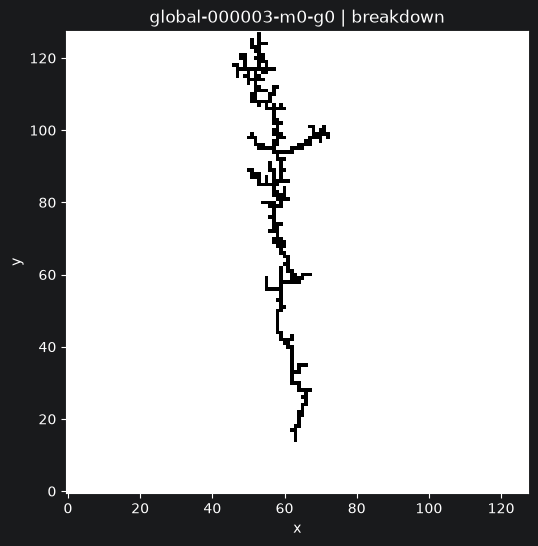

,value
feature,
area,349.000000
area_fraction,0.021301
max_y,127.000000
height_fraction,1.000000
depth_fraction,0.889764
width_fraction,0.204724
x_std_fraction,0.040560
aspect_ratio,0.230088
centroid_offset_fraction,0.042495


In [12]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.imshow(example_mask, cmap="gray_r", origin="lower")
ax.set(
    title=f'{example["run_id"]} | {example["status"]}',
    xlabel="x",
    ylabel="y",
)

plt.show()

display(
    pd.Series(example_features, name="value")
    .rename_axis("feature")
    .to_frame()
)

In [13]:
assert int(example_features["area"]) == int(example["area"])

assert np.isclose(
    example_features["height_fraction"],
    example["height_fraction"],
)

print("area совпадает")
print("height_fraction совпадает")
print("Расчёт реальной маски выполнен корректно")

area совпадает
height_fraction совпадает
Расчёт реальной маски выполнен корректно


## Рассчитываемые морфологические признаки

Для каждой непустой маски канала рассчитываются 27 признаков. Они описывают размер дерева, его пространственную форму, топологию ветвления и распределение массы на разных масштабах.

Реализации со статусом `no_start` не используются, поскольку в них проводящий канал отсутствует и его морфология не определена.

### Геометрические признаки

| Признак | Описание |
|---|---|
| `area` | Общее количество клеток проводящего канала |
| `area_fraction` | Доля всей расчётной сетки, занятая каналом |
| `max_y` | Максимальная вертикальная координата, достигнутая каналом |
| `height_fraction` | Максимальная достигнутая высота, нормированная на высоту сетки |
| `depth_fraction` | Вертикальный размах канала от корня до наиболее глубокой клетки |
| `width_fraction` | Горизонтальный размах канала, нормированный на ширину сетки |
| `x_std_fraction` | Нормированный поперечный разброс клеток канала |
| `aspect_ratio` | Отношение ширины канала к его глубине |
| `centroid_offset_fraction` | Смещение центра массы канала относительно центральной оси образца |
| `anisotropy` | Степень вытянутости канала вдоль преимущественного направления |

Значение `anisotropy`, близкое к нулю, соответствует пространственно равномерной форме. Значение, близкое к единице, соответствует сильно вытянутому каналу.

### Топологические признаки

| Признак | Описание |
|---|---|
| `endpoint_count` | Количество свободных концов ветвей без учёта корня |
| `branching_points` | Количество отдельных областей ветвления |
| `branching_density` | Число ветвлений относительно площади канала |
| `mean_branch_length` | Средняя длина участка между концами и точками ветвления |
| `max_branch_length` | Максимальная длина такого участка |
| `main_path_length` | Длина пути по клеткам от корня до наиболее удалённой глубокой клетки |
| `sinuosity` | Отношение длины основного пути к прямому расстоянию между его концами |
| `side_branch_fraction` | Доля клеток канала, не принадлежащих основному пути |

Для прямого канала `sinuosity` близка к единице. Увеличение значения соответствует более извилистому пути.

Высокая `side_branch_fraction` означает, что значительная часть массы дерева находится в боковых ветвях.

### Фрактальная размерность

| Признак | Описание |
|---|---|
| `fractal_dimension` | Оценка геометрической сложности канала методом box counting |

Фрактальная размерность около единицы соответствует почти линейному каналу. Более высокие значения соответствуют разветвлённым структурам, сильнее заполняющим плоскость.

### Лакунарность

| Признак | Описание |
|---|---|
| `lacunarity_4` | Неоднородность заполнения на масштабе 4 × 4 |
| `lacunarity_8` | Неоднородность заполнения на масштабе 8 × 8 |
| `lacunarity_16` | Неоднородность заполнения на масштабе 16 × 16 |
| `lacunarity_32` | Неоднородность заполнения на масштабе 32 × 32 |

Низкая лакунарность соответствует относительно равномерному распределению клеток. Высокая лакунарность указывает на сочетание плотных участков и крупных пустот между ветвями.

### Радиальный профиль массы

| Признак | Описание |
|---|---|
| `radius_25` | Нормированный радиус, содержащий 25% клеток канала |
| `radius_50` | Нормированный радиус, содержащий 50% клеток канала |
| `radius_75` | Нормированный радиус, содержащий 75% клеток канала |
| `radius_90` | Нормированный радиус, содержащий 90% клеток канала |

Радиусы отсчитываются от корня и нормируются на диагональ расчётной сетки. Вместе они дают компактное описание распределения массы дерева относительно точки старта.

Нормированные признаки позволяют сравнивать каналы независимо от абсолютного размера сетки. Для очень коротких каналов отдельные характеристики, например фрактальная размерность или извилистость, могут быть математически не определены и принимать значение `NaN`. Такие пропуски будут обрабатываться внутри ML-пайплайна.

In [14]:
def calculate_one_morphology(run_id, image_path):
    image_file = DATA_DIR / image_path

    with np.load(image_file, allow_pickle=False) as saved:
        mask = saved["channel"].astype(bool)

    if mask.ndim != 2 or not mask.any():
        raise ValueError(f"Некорректная маска: {run_id}")

    features = compute_morphology_features(mask)

    return {
        "run_id": run_id,
        **{name: features[name] for name in MORPHOLOGY_FEATURES},
    }

In [15]:
import os

N_JOBS = min(4, os.cpu_count() or 1)
BATCH_SIZE = 500

CHECKPOINT_FILE = DATA_DIR / "morphology_checkpoint.csv"

feature_columns = list(MORPHOLOGY_FEATURES)
result_columns = ["run_id", *feature_columns]

assert started["run_id"].notna().all()
assert started["run_id"].is_unique

if CHECKPOINT_FILE.is_file():
    morphology = pd.read_csv(
        CHECKPOINT_FILE,
        dtype={"run_id": "string"},
    )

    assert morphology.columns.tolist() == result_columns
    assert morphology["run_id"].notna().all()
    assert morphology["run_id"].is_unique
    assert morphology["run_id"].isin(started["run_id"]).all()
else:
    morphology = pd.DataFrame(columns=result_columns)

pending = started.loc[
    ~started["run_id"].isin(morphology["run_id"]),
    ["run_id", "image_path"],
].reset_index(drop=True)

print("Процессов:", N_JOBS)
print("Уже рассчитано:", len(morphology))
print("Осталось:", len(pending))

Процессов: 4
Уже рассчитано: 0
Осталось: 10199


In [16]:
with Parallel(n_jobs=N_JOBS) as parallel:
    for start in range(0, len(pending), BATCH_SIZE):
        batch = pending.iloc[start : start + BATCH_SIZE]

        rows = parallel(
            delayed(calculate_one_morphology)(
                row.run_id,
                row.image_path,
            )
            for row in batch.itertuples(index=False)
        )

        batch_features = pd.DataFrame(
            rows,
            columns=result_columns,
        )

        if morphology.empty:
            morphology = batch_features
        else:
            morphology = pd.concat(
                [morphology, batch_features],
                ignore_index=True,
            )

        temporary_file = CHECKPOINT_FILE.with_suffix(".tmp")
        morphology.to_csv(temporary_file, index=False)
        temporary_file.replace(CHECKPOINT_FILE)

        print(
            f"Рассчитано {len(morphology):,} / {len(started):,}",
            flush=True,
        )

print("Расчёт завершён")

Рассчитано 500 / 10,199
Рассчитано 1,000 / 10,199
Рассчитано 1,500 / 10,199
Рассчитано 2,000 / 10,199
Рассчитано 2,500 / 10,199
Рассчитано 3,000 / 10,199
Рассчитано 3,500 / 10,199
Рассчитано 4,000 / 10,199
Рассчитано 4,500 / 10,199
Рассчитано 5,000 / 10,199
Рассчитано 5,500 / 10,199
Рассчитано 6,000 / 10,199
Рассчитано 6,500 / 10,199
Рассчитано 7,000 / 10,199
Рассчитано 7,500 / 10,199
Рассчитано 8,000 / 10,199
Рассчитано 8,500 / 10,199
Рассчитано 9,000 / 10,199
Рассчитано 9,500 / 10,199
Рассчитано 10,000 / 10,199
Рассчитано 10,199 / 10,199
Расчёт завершён


In [17]:
assert morphology["run_id"].is_unique
assert set(morphology["run_id"]) == set(started["run_id"])

morphology = (
    morphology
    .set_index("run_id")
    .loc[started["run_id"]]
    .reset_index()
)

reference = (
    started
    .set_index("run_id")
    .loc[morphology["run_id"]]
)

assert np.allclose(
    morphology["area"],
    reference["area"],
    rtol=0,
    atol=0,
)

assert np.allclose(
    morphology["height_fraction"],
    reference["height_fraction"],
    rtol=0,
    atol=1e-8,
)

assert not np.isinf(
    morphology[feature_columns].to_numpy(dtype=float)
).any()

missing = morphology[feature_columns].isna().sum()

print("Размер таблицы:", morphology.shape)
print("Площадь и высота совпадают с исходными данными")

display(
    missing[missing > 0]
    .sort_values(ascending=False)
    .to_frame("missing_count")
)

Размер таблицы: (10199, 28)
Площадь и высота совпадают с исходными данными


,missing_count
fractal_dimension,320
sinuosity,202
max_branch_length,124
mean_branch_length,124
anisotropy,123


In [18]:
overlapping_features = [
    name
    for name in feature_columns
    if name in started.columns
]

inverse_dataset = (
    started
    .drop(columns=overlapping_features)
    .merge(
        morphology,
        on="run_id",
        how="left",
        validate="one_to_one",
        indicator=True,
    )
)

assert inverse_dataset["_merge"].eq("both").all()

inverse_dataset = inverse_dataset.drop(columns="_merge")

assert len(inverse_dataset) == len(started)

print("Размер датасета обратной задачи:", inverse_dataset.shape)

display(
    inverse_dataset
    .groupby(["split", "status"])
    .size()
    .unstack(fill_value=0)
)

display(inverse_dataset.head())

Размер датасета обратной задачи: (10199, 45)


status,arrested,breakdown
split,,
test,113,1820
train,875,7391


,run_id,point_id,phase,split,material_rep,growth_rep,eta,mean_breakdown_field,correlation_length,weibull_shape,...,side_branch_fraction,fractal_dimension,lacunarity_4,lacunarity_8,lacunarity_16,lacunarity_32,radius_25,radius_50,radius_75,radius_90
0,global-000003-m0-g0,global-000003,global,train,0,0,1.188938,2.922237,2,14.289726,...,0.570201,1.104227,18.874065,12.869254,8.149161,3.907883,0.251538,0.413367,0.513323,0.577493
1,global-000007-m0-g0,global-000007,global,train,0,0,0.787852,2.743639,14,2.879581,...,0.753846,1.334038,13.228443,9.041631,5.374523,4.149738,0.262099,0.385465,0.531860,0.579209
2,global-000008-m0-g0,global-000008,global,train,0,0,0.509025,3.220241,4,6.943663,...,0.783430,1.293139,10.306111,6.864251,5.322607,4.029273,0.356272,0.484476,0.551012,0.579618
3,global-000009-m0-g0,global-000009,global,train,0,0,1.839728,2.881764,15,13.146752,...,0.564706,1.235450,19.682768,12.946159,8.039862,3.912803,0.253364,0.401671,0.476231,0.571268
4,global-000010-m0-g0,global-000010,global,train,0,0,2.930976,3.090365,4,2.767735,...,0.409594,1.078427,23.773097,15.340968,8.277883,4.271619,0.266308,0.496383,0.615528,0.667813


In [19]:
for output_file, frame in [
    (MORPHOLOGY_FILE, morphology),
    (INVERSE_FILE, inverse_dataset),
]:
    temporary_file = output_file.with_suffix(".tmp")

    frame.to_csv(temporary_file, index=False)
    temporary_file.replace(output_file)

    print(f"Сохранено: {output_file.name}")
    print(f"Строк: {len(frame):,}, столбцов: {frame.shape[1]}")

Сохранено: morphology_features.csv
Строк: 10,199, столбцов: 28
Сохранено: dataset_inverse.csv
Строк: 10,199, столбцов: 45


## Расчёт морфологии датасета

Добавлен расчёт **27 морфологических признаков** для **10 199 реализаций с каналом**: 9 211 пробоев и 988 остановившихся деревьев. Реализации `no_start` исключены, поскольку канал отсутствует.

Расчёт выполняется параллельно с сохранением каждых 500 результатов. После остановки можно продолжить обработку оставшихся деревьев.

Проверяются полнота результатов, уникальность `run_id`, совпадение площади и высоты с исходными данными, наличие пропусков и бесконечных значений. Неопределённые признаки коротких каналов сохраняются как `NaN`.

Результаты сохраняются в две таблицы:

- `morphology_features.csv` — идентификаторы и морфологические признаки;
- `dataset_inverse.csv` — признаки вместе с параметрами и статусами симуляций.

Исходное разделение `train/val/test` сохранено. Датасет подготовлен для обратной задачи: восстановления параметров DBM по морфологии дерева.

In [20]:
inverse_dataset = pd.read_csv(
    INVERSE_FILE,
    dtype={
        "disorder_seed": "uint64",
        "random_seed": "uint64",
    },
)

print("Количество реализаций:", len(inverse_dataset))
print("Количество столбцов:", inverse_dataset.shape[1])

display(inverse_dataset.head())

Количество реализаций: 10199
Количество столбцов: 45


,run_id,point_id,phase,split,material_rep,growth_rep,eta,mean_breakdown_field,correlation_length,weibull_shape,...,side_branch_fraction,fractal_dimension,lacunarity_4,lacunarity_8,lacunarity_16,lacunarity_32,radius_25,radius_50,radius_75,radius_90
0,global-000003-m0-g0,global-000003,global,train,0,0,1.188938,2.922237,2,14.289726,...,0.570201,1.104227,18.874065,12.869254,8.149161,3.907883,0.251538,0.413367,0.513323,0.577493
1,global-000007-m0-g0,global-000007,global,train,0,0,0.787852,2.743639,14,2.879581,...,0.753846,1.334038,13.228443,9.041631,5.374523,4.149738,0.262099,0.385465,0.531860,0.579209
2,global-000008-m0-g0,global-000008,global,train,0,0,0.509025,3.220241,4,6.943663,...,0.783430,1.293139,10.306111,6.864251,5.322607,4.029273,0.356272,0.484476,0.551012,0.579618
3,global-000009-m0-g0,global-000009,global,train,0,0,1.839728,2.881764,15,13.146752,...,0.564706,1.235450,19.682768,12.946159,8.039862,3.912803,0.253364,0.401671,0.476231,0.571268
4,global-000010-m0-g0,global-000010,global,train,0,0,2.930976,3.090365,4,2.767735,...,0.409594,1.078427,23.773097,15.340968,8.277883,4.271619,0.266308,0.496383,0.615528,0.667813


In [21]:
split_summary = pd.crosstab(
    inverse_dataset["split"],
    inverse_dataset["status"],
    margins=True,
)

display(split_summary)

status,arrested,breakdown,All
split,,,
test,113,1820,1933
train,875,7391,8266
All,988,9211,10199


In [22]:
print("Дубликаты run_id:", inverse_dataset["run_id"].duplicated().sum())
print("Пустые run_id:", inverse_dataset["run_id"].isna().sum())

assert inverse_dataset["run_id"].notna().all()
assert inverse_dataset["run_id"].is_unique
assert inverse_dataset["split"].notna().all()

print("Базовые проверки пройдены")

Дубликаты run_id: 0
Пустые run_id: 0
Базовые проверки пройдены


In [23]:
TARGET_COLUMNS = [
    "eta",
    "mean_breakdown_field",
    "correlation_length",
    "weibull_shape",
]

MORPHOLOGY_COLUMNS = [
    "area",
    "area_fraction",
    "max_y",
    "height_fraction",
    "depth_fraction",
    "width_fraction",
    "x_std_fraction",
    "aspect_ratio",
    "centroid_offset_fraction",
    "anisotropy",
    "endpoint_count",
    "branching_points",
    "branching_density",
    "mean_branch_length",
    "max_branch_length",
    "main_path_length",
    "sinuosity",
    "side_branch_fraction",
    "fractal_dimension",
    "lacunarity_4",
    "lacunarity_8",
    "lacunarity_16",
    "lacunarity_32",
    "radius_25",
    "radius_50",
    "radius_75",
    "radius_90",
]

assert set(TARGET_COLUMNS).issubset(inverse_dataset.columns)
assert set(MORPHOLOGY_COLUMNS).issubset(inverse_dataset.columns)

print("Целевых параметров:", len(TARGET_COLUMNS))
print("Морфологических признаков:", len(MORPHOLOGY_COLUMNS))

Целевых параметров: 4
Морфологических признаков: 27


In [24]:
missing_summary = (
    inverse_dataset[MORPHOLOGY_COLUMNS + TARGET_COLUMNS]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

display(
    missing_summary[missing_summary > 0]
    .to_frame("missing_count")
)

print(
    "Строк хотя бы с одним пропуском:",
    inverse_dataset[MORPHOLOGY_COLUMNS].isna().any(axis=1).sum(),
)

,missing_count
fractal_dimension,320
sinuosity,202
mean_branch_length,124
max_branch_length,124
anisotropy,123


Строк хотя бы с одним пропуском: 358
